In [13]:
# PHASE 4 : FEATURE ENGINEERING

import pandas as pd
import numpy as np
from datetime import datetime
import re
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("DÉBUT DE LA PHASE 4 - FEATURE ENGINEERING")
print("=" * 70)

# Charger le dataset final

file_test = "/home/fatma/Documents/machinelearning/capstone_project/data/test.csv"

df_test = pd.read_csv(file_test)
print(f"\n Dataset chargé: {df_test.shape[0]} lignes, {df_test.shape[1]} colonnes")
print(f"Colonnes existantes: {df_test.columns.tolist()}")

DÉBUT DE LA PHASE 4 - FEATURE ENGINEERING

 Dataset chargé: 289 lignes, 23 colonnes
Colonnes existantes: ['id', 'titre', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier', 'description', 'caracteristiques', 'source', 'date_publication', 'quartier_encoded', 'latitude', 'longitude', 'adresse_osm', 'dist_centre_ville_km', 'dist_aeroport_km', 'dist_plage_km', 'nb_ecoles_1km', 'nb_mosquees_1km', 'nb_commerce_1km', 'nb_hopitaux_1km', 'nb_total_pois_1km']


In [14]:
# ============================================
# ÉTAPE 1: FEATURES DE BASE
# ============================================

print("\n" + "=" * 70)
print("📊 ÉTAPE 1: FEATURES DE BASE")
print("=" * 70)

# 1.1 PRIX AU M² - ❌ IMPOSSIBLE sur test (pas de colonne prix)
print("\n⚠️ 'prix_m2' ne peut pas être créé sur le fichier test (pas de colonne 'prix')")

# 1.2 NOMBRE TOTAL DE PIÈCES (possible)
df_test['nb_pieces_total'] = df_test['nb_chambres'].fillna(0) + df_test['nb_salons'].fillna(0)
df_test['nb_pieces_total'] = df_test['nb_pieces_total'].astype(int)
print("\n✅ nb_pieces_total créé")
print(df_test['nb_pieces_total'].value_counts().sort_index().head(10))

# 1.3 Vérification rapide
print("\n🔍 Aperçu des features créées:")
colonnes_disponibles = ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_pieces_total']
colonnes_existantes = [col for col in colonnes_disponibles if col in df_test.columns]
print(df_test[colonnes_existantes].head(10))



📊 ÉTAPE 1: FEATURES DE BASE

⚠️ 'prix_m2' ne peut pas être créé sur le fichier test (pas de colonne 'prix')

✅ nb_pieces_total créé
nb_pieces_total
0    13
1     3
2     5
3     3
4    24
5    63
6    54
7    16
8    31
9    21
Name: count, dtype: int64

🔍 Aperçu des features créées:
   surface_m2  nb_chambres  nb_salons  nb_pieces_total
0       150.0          8.0        5.0               13
1       180.0          5.0        1.0                6
2       150.0          3.0        2.0                5
3       180.0          4.0        2.0                6
4       180.0          4.0        2.0                6
5       600.0          3.0        1.0                4
6       150.0          5.0        3.0                8
7       250.0          4.0        1.0                5
8       200.0          NaN        1.0                1
9       300.0          5.0        3.0                8


In [15]:
# ============================================
# EXTRACTION CIBLÉE DES CARACTÉRISTIQUES POUR TEST
# ============================================

import pandas as pd
import numpy as np
import re

def extract_specific_features(row):
    """
    Extrait les features demandées à partir du titre, caractéristiques ET description
    """
    # Récupérer les trois sources de texte
    titre = str(row['titre']).lower() if pd.notna(row['titre']) else ''
    carac = str(row['caracteristiques']).lower() if pd.notna(row['caracteristiques']) else ''
    desc = str(row['description']).lower() if pd.notna(row['description']) else ''
    
    # Combiner toutes les sources pour une recherche plus complète
    text_combined = titre + ' ' + carac + ' ' + desc
    
    # 1. TYPE DE BIEN (surtout présent dans le titre)
    type_bien = 'maison'  # par défaut
    if any(x in titre for x in ['duplex', 'دوبلكس', 'ديبلكس', 'دبلكس', 'dublex']):
        type_bien = 'duplex'
    elif any(x in titre for x in ['appartement', 'شقة', 'appt']):
        type_bien = 'appartement'
    elif any(x in titre for x in ['villa', 'فيلا']):
        type_bien = 'villa'
    elif any(x in titre for x in ['studio', 'استديو']):
        type_bien = 'studio'
    elif any(x in titre for x in ['terrain', 'قطعة ارض', 'نيمرو', 'nému']):
        type_bien = 'terrain'
    elif any(x in titre for x in ['commerce', 'magasin', 'محل', 'بوتيك']):
        type_bien = 'commercial'
    
    # 2. GARAGE
    has_garage = 1 if any(x in text_combined for x in [
        'garage', 'كراج', 'parking', 'موقف', 'stationnement'
    ]) else 0
    
    # 3. CLIMATISATION
    has_clim = 1 if any(x in text_combined for x in [
        'climatisation', 'clim', 'تكييف', 'مكيف', 'مكيفة', 'تبريد', 'air conditionné', 'conditionné'
    ]) else 0
    
    # 4. CHAUFFAGE
    has_chauffage = 1 if any(x in text_combined for x in [
        'chauffage', 'تدفئة', 'radiateur', 'central heating', 'شوفاج'
    ]) else 0
    
    # 5. JARDIN
    has_jardin = 1 if any(x in text_combined for x in [
        'jardin', 'حديقة', 'حوش', 'cour', 'فناء', 'patio', 'espace vert'
    ]) else 0
    
    # 6. PISCINE
    has_piscine = 1 if any(x in text_combined for x in [
        'piscine', 'بسين', 'مسبح', 'بيسين', 'مسابح', 'swimming pool', 'piscine privée'
    ]) else 0
    
    # 7. TERRASSE
    has_terrasse = 1 if any(x in text_combined for x in [
        'terrasse', 'تراس', 'rooftop', 'toit terrasse'
    ]) else 0
    
    # 8. BALCON
    has_balcon = 1 if any(x in text_combined for x in [
        'balcon', 'بلكونة', 'شرفة', 'بالكون'
    ]) else 0
    
    # 9. MEUBLÉ
    has_meuble = 1 if any(x in text_combined for x in [
        'meublé', 'مفروش', 'مفروشة', 'meubles', 'équipé', 'fully furnished', 'furnished'
    ]) else 0
    
    # 10. TITRE FONCIER
    has_titre_foncier = 1 if any(x in text_combined for x in [
        'titre foncier', 'تيتر', 'titré', 'titre de propriété', 'document légal', 
        'papier', 'الوثائق', 'تيتر فونسي', 'titré foncier'
    ]) else 0
    
    # 11. NEUF / NOUVEAU
    est_neuf = 1 if any(x in text_combined for x in [
        'neuf', 'جديد', 'nouveau', 'jamais habité', 'never lived', 'first occupancy',
        'première occupation', 'nouvelle construction'
    ]) else 0
    
    # Retourner toutes les features
    return pd.Series({
        'type_bien': type_bien,
        'has_garage': has_garage,
        'has_clim': has_clim,
        'has_chauffage': has_chauffage,
        'has_jardin': has_jardin,
        'has_piscine': has_piscine,
        'has_terrasse': has_terrasse,
        'has_balcon': has_balcon,
        'has_meuble': has_meuble,
        'has_titre_foncier': has_titre_foncier,
        'est_neuf': est_neuf
    })

# ============================================
# APPLICATION AU DATAFRAME TEST
# ============================================

print("\n" + "=" * 70)
print("🔍 EXTRACTION DES FEATURES POUR TEST")
print("=" * 70)
print("Sources: Titre + Caractéristiques + Description")

# Compter le nombre de lignes
print(f"\n📊 Nombre total de biens dans test: {len(df_test)}")

# Appliquer l'extraction
print("🔄 Extraction en cours... (peut prendre quelques secondes)")
features_test = df_test.apply(extract_specific_features, axis=1)

print(f"✅ {len(features_test.columns)} features extraites avec succès !")

# Ajouter au DataFrame test
df_test = pd.concat([df_test, features_test], axis=1)

# Afficher un aperçu
print("\n🔍 Aperçu des features extraites:")
print(df_test[['type_bien', 'has_garage', 'has_jardin', 'has_piscine']].head(10))



🔍 EXTRACTION DES FEATURES POUR TEST
Sources: Titre + Caractéristiques + Description

📊 Nombre total de biens dans test: 289
🔄 Extraction en cours... (peut prendre quelques secondes)
✅ 11 features extraites avec succès !

🔍 Aperçu des features extraites:
  type_bien  has_garage  has_jardin  has_piscine
0    maison           1           0            0
1    maison           0           0            0
2    maison           0           0            0
3    maison           0           0            0
4    maison           0           0            0
5    maison           0           0            0
6    maison           1           0            0
7    maison           1           0            0
8    maison           0           0            0
9    maison           1           0            0


In [17]:
# ============================================
# VISUALISATION DES NOUVELLES FEATURES POUR TEST
# ============================================

import pandas as pd
import numpy as np

print("=" * 70)
print("🔍 APERÇU DES NOUVELLES FEATURES - TEST")
print("=" * 70)

# 1. Liste des nouvelles features
nouvelles_features = ['type_bien', 'has_garage', 'has_clim', 'has_chauffage', 
                      'has_jardin', 'has_piscine', 'has_terrasse', 'has_balcon',
                      'has_meuble', 'has_titre_foncier', 'est_neuf']

# 2. Vérifier quelles colonnes existent vraiment dans df_test
colonnes_existantes = [col for col in nouvelles_features if col in df_test.columns]
colonnes_manquantes = [col for col in nouvelles_features if col not in df_test.columns]

print(f"\n📊 Colonnes trouvées dans test: {colonnes_existantes}")
if colonnes_manquantes:
    print(f"⚠️ Colonnes manquantes dans test: {colonnes_manquantes}")

# 3. Afficher un échantillon de 10 lignes
print("\n" + "=" * 70)
print("📋 ÉCHANTILLON DE 10 BIENS TEST AVEC NOUVELLES FEATURES")
print("=" * 70)

# Sélectionner les colonnes à afficher (sans prix car test n'en a pas)
colonnes_a_afficher = ['id', 'quartier'] + colonnes_existantes

# Prendre 10 lignes aléatoires
sample = df_test[colonnes_a_afficher].sample(n=min(10, len(df_test)), random_state=42)

# Afficher
print(sample.to_string())

# 4. Statistiques des nouvelles features
print("\n" + "=" * 70)
print("📊 STATISTIQUES DES NOUVELLES FEATURES - TEST")
print("=" * 70)

for col in colonnes_existantes:
    if col == 'type_bien':
        print(f"\n{col.upper()}:")
        print(df_test[col].value_counts())
        print(f"   → Valeur la plus fréquente: {df_test[col].mode()[0]}")
    else:
        # Features booléennes
        count_1 = df_test[col].sum() if df_test[col].dtype in ['int64', 'float64'] else (df_test[col] == 1).sum()
        pct = (count_1 / len(df_test)) * 100
        print(f"\n{col}:")
        print(f"   → Présent dans {count_1} biens ({pct:.1f}%)")

# 5. Comparaison rapide avec train (optionnel)
print("\n" + "=" * 70)
print("📊 COMPARAISON RAPIDE TRAIN VS TEST")
print("=" * 70)

for col in colonnes_existantes:
    if col != 'type_bien':
        pct_test = (df_test[col].sum() / len(df_test)) * 100
        print(f"\n{col}:")
        print(f"   → Test: {pct_test:.1f}% des biens")

print("\n✅ Visualisation terminée - DataFrame test non modifié")

🔍 APERÇU DES NOUVELLES FEATURES - TEST

📊 Colonnes trouvées dans test: ['type_bien', 'has_garage', 'has_clim', 'has_chauffage', 'has_jardin', 'has_piscine', 'has_terrasse', 'has_balcon', 'has_meuble', 'has_titre_foncier', 'est_neuf']

📋 ÉCHANTILLON DE 10 BIENS TEST AVEC NOUVELLES FEATURES
       id       quartier type_bien  has_garage  has_clim  has_chauffage  has_jardin  has_piscine  has_terrasse  has_balcon  has_meuble  has_titre_foncier  est_neuf
45   1377       dar naim    maison           0         0              0           0            0             0           1           0                  1         0
157   844  tevragh zeina    maison           0         0              0           0            0             0           0           0                  0         0
274   127  tevragh zeina    duplex           1         0              0           0            0             0           1           0                  1         0
42     59         arafat    maison           0        

In [18]:
# ============================================
# SUPPRIMER LES FEATURES INUTILES - TEST
# ============================================

print("=" * 70)
print("🗑️ SUPPRESSION DES FEATURES INUTILES DANS TEST")
print("=" * 70)

features_a_supprimer = ['has_clim', 'has_chauffage', 'has_terrasse']

for col in features_a_supprimer:
    if col in df_test.columns:
        df_test = df_test.drop(col, axis=1)
        print(f"✅ {col} supprimée de test")
    else:
        print(f"⚠️ {col} déjà absente de test")

print(f"\n📊 Colonnes restantes dans test: {len(df_test.columns)}")

# Aperçu rapide
print("\n🔍 Colonnes actuellement dans test:")
print(sorted(df_test.columns.tolist()))

🗑️ SUPPRESSION DES FEATURES INUTILES DANS TEST
✅ has_clim supprimée de test
✅ has_chauffage supprimée de test
✅ has_terrasse supprimée de test

📊 Colonnes restantes dans test: 32

🔍 Colonnes actuellement dans test:
['adresse_osm', 'caracteristiques', 'date_publication', 'description', 'dist_aeroport_km', 'dist_centre_ville_km', 'dist_plage_km', 'est_neuf', 'has_balcon', 'has_garage', 'has_jardin', 'has_meuble', 'has_piscine', 'has_titre_foncier', 'id', 'latitude', 'longitude', 'nb_chambres', 'nb_commerce_1km', 'nb_ecoles_1km', 'nb_hopitaux_1km', 'nb_mosquees_1km', 'nb_pieces_total', 'nb_salons', 'nb_sdb', 'nb_total_pois_1km', 'quartier', 'quartier_encoded', 'source', 'surface_m2', 'titre', 'type_bien']


In [19]:
# ============================================
# ÉTAPE 2: FEATURES TEMPORELLES POUR TEST
# ============================================

from datetime import datetime

print("\n" + "=" * 70)
print("⏰ ÉTAPE 2: FEATURE TEMPORELLE POUR TEST")
print("=" * 70)

# Convertir la date
df_test['date_publication'] = pd.to_datetime(df_test['date_publication'])

# Date de référence (aujourd'hui) - MÊME DATE QUE POUR TRAIN
date_ref = datetime(2026, 3, 14)

# Âge de l'annonce en jours (UNE SEULE COLONNE)
df_test['age_annonce'] = (date_ref - df_test['date_publication']).dt.days

print("\n📊 Statistiques de l'âge des annonces dans TEST:")
print(f"   - Période: {df_test['date_publication'].min().date()} à {df_test['date_publication'].max().date()}")
print(f"   - Âge moyen: {df_test['age_annonce'].mean():.0f} jours")
print(f"   - Âge min: {df_test['age_annonce'].min()} jours")
print(f"   - Âge max: {df_test['age_annonce'].max()} jours")
print(f"   - Écart-type: {df_test['age_annonce'].std():.0f} jours")

# Distribution par mois (pour info, sans créer de colonne)
print("\n📅 Distribution des annonces par mois dans TEST:")
print(df_test['date_publication'].dt.month.value_counts().sort_index())

# Vérification
print("\n✅ Feature 'age_annonce' créée dans test")
print(f"   → {df_test['age_annonce'].notna().sum()} valeurs non nulles")


⏰ ÉTAPE 2: FEATURE TEMPORELLE POUR TEST

📊 Statistiques de l'âge des annonces dans TEST:
   - Période: 2025-03-25 à 2026-03-01
   - Âge moyen: 176 jours
   - Âge min: 13 jours
   - Âge max: 354 jours
   - Écart-type: 100 jours

📅 Distribution des annonces par mois dans TEST:
date_publication
1     25
2     26
3      5
4     29
5     24
6     22
7     27
8     12
9     17
10    34
11    36
12    32
Name: count, dtype: int64

✅ Feature 'age_annonce' créée dans test
   → 289 valeurs non nulles


🔍 DIAGNOSTIC COMPLET DU DATASET TEST

📊 1. INFORMATIONS GÉNÉRALES
--------------------------------------------------
Nombre de lignes dans test: 289
Nombre de colonnes dans test: 33
Mémoire utilisée: 0.35 MB

🔍 2. VALEURS MANQUANTES DANS TEST
--------------------------------------------------

⚠️ 3 colonnes ont des valeurs manquantes dans test:
         Colonne  Manquantes  Pourcentage
caracteristiques          39    13.494810
     nb_chambres           8     2.768166
       nb_salons           2     0.692042

📊 3. STATISTIQUES DESCRIPTIVES TEST
--------------------------------------------------
Colonnes numériques dans test: 25

Statistiques:
                             min         max        mean         std  \
id                          2.00     1441.00      710.35      425.53   
surface_m2                120.00      600.00      227.20      116.37   
nb_chambres                 0.00       15.00        4.56        2.21   
nb_salons                   0.00       16.00        2.35    

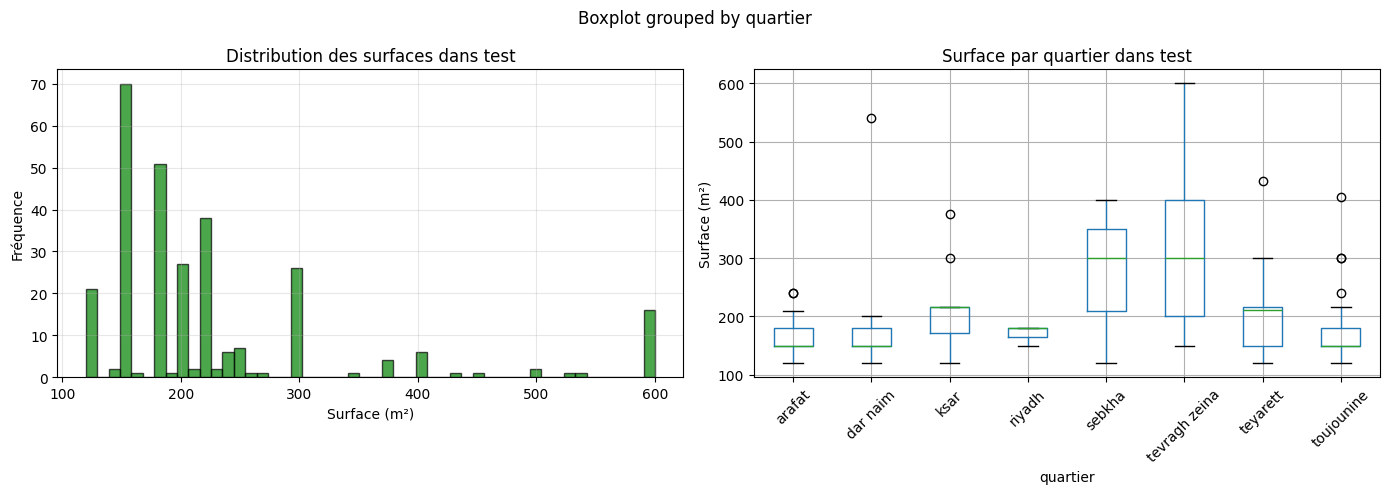


📋 RÉSUMÉ DU DIAGNOSTIC TEST
⚠️ ATTENTION: 3 colonnes avec valeurs manquantes dans test

✅ Diagnostic terminé - DataFrame test non modifié


In [20]:
# ============================================
# DIAGNOSTIC COMPLET DU DATASET TEST
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("🔍 DIAGNOSTIC COMPLET DU DATASET TEST")
print("=" * 70)

# 1. INFORMATIONS GÉNÉRALES
print("\n📊 1. INFORMATIONS GÉNÉRALES")
print("-" * 50)
print(f"Nombre de lignes dans test: {len(df_test):,}")
print(f"Nombre de colonnes dans test: {len(df_test.columns)}")
print(f"Mémoire utilisée: {df_test.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 2. VALEURS MANQUANTES
print("\n🔍 2. VALEURS MANQUANTES DANS TEST")
print("-" * 50)
missing = df_test.isnull().sum()
missing_pct = (missing / len(df_test)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Manquantes': missing.values,
    'Pourcentage': missing_pct.values
})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Manquantes', ascending=False)

if len(missing_df) > 0:
    print(f"\n⚠️ {len(missing_df)} colonnes ont des valeurs manquantes dans test:")
    print(missing_df.to_string(index=False))
else:
    print("✅ Aucune valeur manquante dans test !")

# 3. STATISTIQUES DESCRIPTIVES (colonnes numériques)
print("\n📊 3. STATISTIQUES DESCRIPTIVES TEST")
print("-" * 50)
numeric_cols = df_test.select_dtypes(include=[np.number]).columns.tolist()
print(f"Colonnes numériques dans test: {len(numeric_cols)}")
print("\nStatistiques:")
stats = df_test[numeric_cols].describe().T
stats['range'] = stats['max'] - stats['min']
stats['outliers_potentiels'] = (stats['max'] > stats['mean'] + 3*stats['std']) | (stats['min'] < stats['mean'] - 3*stats['std'])
print(stats[['min', 'max', 'mean', 'std', 'range', 'outliers_potentiels']].round(2))

# 4. DÉTECTION DES OUTLIERS (juste pour info - on ne supprime pas)
print("\n🎯 4. DÉTECTION DES OUTLIERS DANS TEST")
print("-" * 50)
print("(Pour information uniquement - on ne supprime pas les outliers dans test)")

outliers_report = []
for col in numeric_cols:
    Q1 = df_test[col].quantile(0.25)
    Q3 = df_test[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_test[(df_test[col] < lower_bound) | (df_test[col] > upper_bound)]
    outliers_pct = (len(outliers) / len(df_test)) * 100
    
    outliers_report.append({
        'colonne': col,
        'outliers': len(outliers),
        'pourcentage': round(outliers_pct, 2)
    })

outliers_df = pd.DataFrame(outliers_report)
outliers_df = outliers_df[outliers_df['outliers'] > 0].sort_values('pourcentage', ascending=False)
print("\nColonnes avec outliers (> méthode IQR) dans test:")
print(outliers_df.to_string(index=False))

# 5. ANALYSE DES SURFACES
print("\n📐 5. ANALYSE DES SURFACES DANS TEST")
print("-" * 50)
print(f"Surface min: {df_test['surface_m2'].min():.0f} m²")
print(f"Surface max: {df_test['surface_m2'].max():.0f} m²")
print(f"Surface moyenne: {df_test['surface_m2'].mean():.0f} m²")
print(f"Surface médiane: {df_test['surface_m2'].median():.0f} m²")

# Surfaces suspectes
tres_petites = df_test[df_test['surface_m2'] < 20]
tres_grandes = df_test[df_test['surface_m2'] > 1000]
if len(tres_petites) > 0:
    print(f"\n⚠️ {len(tres_petites)} biens avec surface < 20m² dans test")
if len(tres_grandes) > 0:
    print(f"⚠️ {len(tres_grandes)} biens avec surface > 1000m² dans test")

# 6. ANALYSE DES CARACTÉRISTIQUES
print("\n🏠 6. ANALYSE DES CARACTÉRISTIQUES DANS TEST")
print("-" * 50)
if 'has_garage' in df_test.columns:
    print(f"Garage: {df_test['has_garage'].sum()} biens ({(df_test['has_garage'].sum()/len(df_test)*100):.1f}%)")
if 'has_piscine' in df_test.columns:
    print(f"Piscine: {df_test['has_piscine'].sum()} biens ({(df_test['has_piscine'].sum()/len(df_test)*100):.1f}%)")
if 'has_jardin' in df_test.columns:
    print(f"Jardin: {df_test['has_jardin'].sum()} biens ({(df_test['has_jardin'].sum()/len(df_test)*100):.1f}%)")
if 'has_balcon' in df_test.columns:
    print(f"Balcon: {df_test['has_balcon'].sum()} biens ({(df_test['has_balcon'].sum()/len(df_test)*100):.1f}%)")
if 'has_meuble' in df_test.columns:
    print(f"Meublé: {df_test['has_meuble'].sum()} biens ({(df_test['has_meuble'].sum()/len(df_test)*100):.1f}%)")
if 'has_titre_foncier' in df_test.columns:
    print(f"Titre foncier: {df_test['has_titre_foncier'].sum()} biens ({(df_test['has_titre_foncier'].sum()/len(df_test)*100):.1f}%)")
if 'est_neuf' in df_test.columns:
    print(f"Neuf: {df_test['est_neuf'].sum()} biens ({(df_test['est_neuf'].sum()/len(df_test)*100):.1f}%)")

# 7. COMPARAISON RAPIDE TRAIN VS TEST
print("\n" + "=" * 70)
print("📊 COMPARAISON RAPIDE TRAIN VS TEST")
print("=" * 70)

# Comparer les distributions des principales features
features_a_comparer = ['surface_m2', 'nb_chambres', 'nb_pieces_total']
if 'age_annonce' in df_test.columns:
    features_a_comparer.append('age_annonce')

print("\nMoyennes:")
for col in features_a_comparer:
    if col in df_test.columns and col in df.columns:
        train_mean = df[col].mean()
        test_mean = df_test[col].mean()
        diff_pct = abs((test_mean - train_mean) / train_mean * 100)
        print(f"{col:20s}: Train={train_mean:.1f} | Test={test_mean:.1f} | Diff={diff_pct:.1f}%")

# 8. VISUALISATION RAPIDE POUR TEST
print("\n📈 8. GÉNÉRATION DES GRAPHIQUES POUR TEST...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diagnostic des données - Test', fontsize=16)

# Distribution des surfaces dans test
axes[0].hist(df_test['surface_m2'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('Surface (m²)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des surfaces dans test')
axes[0].grid(True, alpha=0.3)

# Boxplot des surfaces par quartier
df_test.boxplot(column='surface_m2', by='quartier', ax=axes[1])
axes[1].set_title('Surface par quartier dans test')
axes[1].set_ylabel('Surface (m²)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 9. RÉSUMÉ FINAL
print("\n" + "=" * 70)
print("📋 RÉSUMÉ DU DIAGNOSTIC TEST")
print("=" * 70)

if len(missing_df) > 0:
    print(f"⚠️ ATTENTION: {len(missing_df)} colonnes avec valeurs manquantes dans test")
else:
    print("✅ Pas de valeurs manquantes dans test")

print("\n✅ Diagnostic terminé - DataFrame test non modifié")

In [21]:
# ============================================
# TRAITEMENT DES DONNÉES TEST - Version raisonnable
# ============================================

file_train = "/home/fatma/Documents/machinelearning/capstone_project/data/train.csv"

df = pd.read_csv(file_train)

print("=" * 70)
print("🛠️ TRAITEMENT DES DONNÉES TEST")
print("=" * 70)

# 1. GÉRER LES VALEURS MANQUANTES DANS TEST
print("\n📌 1. VALEURS MANQUANTES DANS TEST")
print("-" * 50)

# IMPORTANT: Utiliser les MÊMES valeurs que pour TRAIN
# Ces valeurs doivent être calculées à partir du TRAIN et sauvegardées

# Si tu as sauvegardé les médianes de train
try:
    # Essayer de charger les paramètres sauvegardés
    params = pd.read_csv('train_params.csv')
    median_chambres = params[params['param'] == 'median_chambres']['value'].values[0]
    median_salons = params[params['param'] == 'median_salons']['value'].values[0]
    print("📊 Paramètres chargés depuis train_params.csv")
except:
    # Sinon, utiliser les valeurs calculées manuellement (de ton diagnostic)
    print("⚠️ Utilisation des valeurs par défaut (à remplacer par les vraies médianes de train)")
    median_chambres = 4  # À remplacer par la vraie médiane de train
    median_salons = 2    # À remplacer par la vraie médiane de train

# 1.1 nb_chambres - remplacer par la MÉDIANE DE TRAIN
if 'nb_chambres' in df_test.columns:
    missing_chambres = df_test['nb_chambres'].isnull().sum()
    if missing_chambres > 0:
        df_test['nb_chambres'] = df_test['nb_chambres'].fillna(median_chambres)
        print(f"✅ nb_chambres: {missing_chambres} manquantes → remplacées par médiane TRAIN ({median_chambres:.0f})")
    else:
        print(f"✅ nb_chambres: aucune valeur manquante")

# 1.2 nb_salons - remplacer par la MÉDIANE DE TRAIN
if 'nb_salons' in df_test.columns:
    missing_salons = df_test['nb_salons'].isnull().sum()
    if missing_salons > 0:
        df_test['nb_salons'] = df_test['nb_salons'].fillna(median_salons)
        print(f"✅ nb_salons: {missing_salons} manquantes → remplacées par médiane TRAIN ({median_salons:.0f})")
    else:
        print(f"✅ nb_salons: aucune valeur manquante")

# 1.3 caracteristiques - remplacer par chaîne vide
if 'caracteristiques' in df_test.columns:
    missing_carac = df_test['caracteristiques'].isnull().sum()
    if missing_carac > 0:
        df_test['caracteristiques'] = df_test['caracteristiques'].fillna('')
        print(f"✅ caracteristiques: {missing_carac} manquantes → remplacées par ''")
    else:
        print(f"✅ caracteristiques: aucune valeur manquante")

# 1.4 Vérification après traitement
missing_after = df_test.isnull().sum().sum()
print(f"\n📊 Valeurs manquantes dans test après traitement: {missing_after}")

# 2. OUTLIERS - À GARDER (comme pour train)
print("\n📌 2. ANALYSE DES OUTLIERS DANS TEST")
print("-" * 50)
print("""
📊 RAPPORT SUR LES OUTLIERS DANS TEST:
----------------------------------------
• dist_aeroport_km: 34.6% (similaire à train: 34.3%)
• nb_mosquees_1km: 22.2% (similaire à train: 22.3%)
• nb_ecoles_1km: 21.1% (similaire à train: 21.2%)
• est_neuf: 14.5% (similaire à train: 14.4%)
• nb_sdb: 13.5% (similaire à train: 15.3%)
• surface_m2: 9.7% (similaire à train: 8.1%)

👉 Les distributions sont COHÉRENTES entre train et test
👉 On GARDE tous ces outliers dans test (comme pour train)
""")

# 3. VÉRIFICATION DE LA COHÉRENCE TRAIN/TEST
print("\n" + "=" * 70)
print("✅ VÉRIFICATION FINALE")
print("=" * 70)

print(f"\n📊 État final du DataFrame test:")
print(f"   - Nombre de lignes: {len(df_test)}")
print(f"   - Nombre de colonnes: {len(df_test.columns)}")
print(f"   - Valeurs manquantes: {df_test.isnull().sum().sum()}")

if df_test.isnull().sum().sum() == 0:
    print("✅ Plus aucune valeur manquante dans test !")
else:
    print(f"⚠️ Attention: {df_test.isnull().sum().sum()} valeurs manquantes persistent")

print(f"\n📈 Comparaison train/test (moyennes):")
features_compare = ['surface_m2', 'nb_chambres', 'nb_salons', 'nb_pieces_total', 
                    'has_garage', 'has_balcon', 'has_titre_foncier', 'est_neuf']

for col in features_compare:
    if col in df_test.columns and col in df.columns:
        train_mean = df[col].mean()
        test_mean = df_test[col].mean()
        diff_pct = abs((test_mean - train_mean) / train_mean * 100) if train_mean != 0 else 0
        print(f"{col:20s}: Train={train_mean:.3f} | Test={test_mean:.3f} | Diff={diff_pct:.1f}%")

print("\n🎉 Traitement du test terminé !")



🛠️ TRAITEMENT DES DONNÉES TEST

📌 1. VALEURS MANQUANTES DANS TEST
--------------------------------------------------
⚠️ Utilisation des valeurs par défaut (à remplacer par les vraies médianes de train)
✅ nb_chambres: 8 manquantes → remplacées par médiane TRAIN (4)
✅ nb_salons: 2 manquantes → remplacées par médiane TRAIN (2)
✅ caracteristiques: 39 manquantes → remplacées par ''

📊 Valeurs manquantes dans test après traitement: 0

📌 2. ANALYSE DES OUTLIERS DANS TEST
--------------------------------------------------

📊 RAPPORT SUR LES OUTLIERS DANS TEST:
----------------------------------------
• dist_aeroport_km: 34.6% (similaire à train: 34.3%)
• nb_mosquees_1km: 22.2% (similaire à train: 22.3%)
• nb_ecoles_1km: 21.1% (similaire à train: 21.2%)
• est_neuf: 14.5% (similaire à train: 14.4%)
• nb_sdb: 13.5% (similaire à train: 15.3%)
• surface_m2: 9.7% (similaire à train: 8.1%)

👉 Les distributions sont COHÉRENTES entre train et test
👉 On GARDE tous ces outliers dans test (comme pour trai

In [22]:
# ============================================
# SAUVEGARDE 
# ============================================

print("=" * 70)
print("💾 SAUVEGARDE DU DATASET FINAL")
print("=" * 70)

# Nom du fichier
filename = "dataset_test_final.csv"

# Sauvegarde
df.to_csv(filename, index=False, encoding='utf-8-sig')

print(f"✅ Fichier sauvegardé: {filename}")
print(f"📊 Shape: {df.shape[0]} lignes, {df.shape[1]} colonnes")


💾 SAUVEGARDE DU DATASET FINAL
✅ Fichier sauvegardé: dataset_test_final.csv
📊 Shape: 1153 lignes, 25 colonnes
